In [ ]:
import pandas as pd

meta_table = pd.read_csv('gse40279_meta.csv', delimiter=',')
meta_table.index = ['Age', 'Description', 'GEO']
raw_table = pd.read_csv('GSE40279_average_beta.txt', delimiter='\t', index_col=0)

with open("cd_74_associated_cpgs.txt") as file:
    lines = file.read().splitlines()
cd_74_associated_cpgs_set=set(lines)
raw_table = raw_table[raw_table.index.isin(cd_74_associated_cpgs_set)] #1293 CPG SITES LEFT (10 WAS MISSING FROM THE SAMPLES, BUT COVERED IN ILLUMNIA)
raw_table

,X1001,X1002,X1003,X1004,X1005,X1006,X1007,X1008,X1009,X1010,...,X11085,X11086,X11087,X11089,X11090,X11092,X11093,X11094,X11095,X11096
ID_REF,,,,,,,,,,,,,,,,,,,,,
cg11843502,0.174863,0.199667,0.197990,0.189053,0.203709,0.168005,0.198806,0.170518,0.181513,0.186998,...,0.185103,0.172349,0.167645,0.176240,0.127520,0.180176,0.147239,0.169246,0.163711,0.129589
cg06487986,0.074686,0.065040,0.069715,0.053284,0.062058,0.052559,0.065618,0.065432,0.063987,0.074606,...,0.073007,0.066565,0.068357,0.049509,0.047468,0.064470,0.057758,0.057910,0.053885,0.041685
cg23927002,0.021214,0.036691,0.039626,0.046974,0.037283,0.055979,0.025497,0.034783,0.036062,0.031837,...,0.052336,0.039500,0.043066,0.046578,0.055033,0.055391,0.038604,0.033557,0.055425,0.043548
cg11753033,0.017043,0.016005,0.017115,0.026354,0.030088,0.003177,0.022032,0.013876,0.015035,0.018376,...,0.013547,0.016106,0.005018,0.019529,0.013940,0.005900,0.013367,0.006856,0.000000,0.000000
cg17465881,0.060516,0.079828,0.058642,0.082066,0.068319,0.092545,0.059744,0.056169,0.088278,0.067179,...,0.063336,0.078196,0.073195,0.060206,0.042385,0.064448,0.074746,0.065013,0.060495,0.052780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg16176048,0.022002,0.018104,0.016378,0.020735,0.017148,0.030058,0.018656,0.017493,0.023747,0.023302,...,0.001381,0.003087,0.000000,0.000528,0.000000,0.009722,0.000959,0.000000,0.004542,0.000000
cg27447689,0.050004,0.040150,0.050553,0.049412,0.053590,0.049570,0.048031,0.047594,0.040301,0.051148,...,0.054670,0.062899,0.057988,0.045591,0.037106,0.059920,0.050703,0.045642,0.045757,0.044382
cg21974239,0.067605,0.054013,0.064951,0.061928,0.074344,0.089312,0.070982,0.069145,0.079136,0.066163,...,0.084709,0.077888,0.101311,0.106954,0.082946,0.085487,0.094217,0.089353,0.096273,0.095045


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np


class MethylationDataset(Dataset):
    def __init__(self, meta_table, raw_table, transform=None):
        self.meta_table = meta_table
        self.raw_table = raw_table
        
    def __len__(self):
        return self.raw_table.shape[1]

    def __getitem__(self, idx):
        # Ensure the index is within the bounds of the meta_table
        if idx >= self.__len__():
            print('Index out of bounds:', idx)
            return -1

        # Extract the RNA data and age
        try:
            rna_data = self.raw_table.iloc[:, idx].tolist()
            age=float(self.meta_table.iloc[0,idx])
        except IndexError as e:
            print(f"IndexError: {e}, idx: {idx}")
            return -1
        return torch.tensor(rna_data), age
    
    def get_features_and_targets(self):
        features = []
        targets = []
        for idx in range(len(self)):
            rna_data, age = self[idx]
            features.append(rna_data.numpy())
            targets.append(age.numpy())
        return np.array(features), np.array(targets)

In [ ]:
#save for later faster use
raw_table.to_csv('raw_table_inflammation_genes_only.csv', sep='\t', index=True)

In [ ]:
raw_table.index.to_series().rename("ID").to_csv("hannum_elnet_cg_order.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split

#CREATE THE DATSET, AND HAVE A RNANDOM SPLIT FOR TRAINING AND TESTING 80-20
transcriptomic_dataset = MethylationDataset(meta_table,raw_table)

train_data, test_data = train_test_split(transcriptomic_dataset, test_size=0.2, random_state=42)
#Print the sizes of the train and test datasets
print("Train data size:", len(train_data))
print("Test data size:", len(test_data))

Train data size: 524
Test data size: 132


In [ ]:
# Initialize lists for features and targets
X_train = []
y_train = []

for features, target in train_data:
    X_train.append(features)
    y_train.append(target)

X_test = []
y_test = []

for features, target in test_data:
    X_test.append(features)
    y_test.append(target)

In [6]:
import warnings
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.storage")

# Define the pipeline
pipeline = make_pipeline(
    MinMaxScaler(),            
    ElasticNet(max_iter=10000)
)

# Define the parameter grid
param_grid = {
    'elasticnet__alpha': np.linspace(0.0001, 1, 20),    # 50 values between 0.001 and 1
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 10)  # 30 values between 0.1 and 0.9
}


# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    #scoring='neg_mean_squared_error',
    scoring='neg_mean_absolute_error',
    n_jobs=2,
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", -grid_search.best_score_)

# Extract the best model
best_model = grid_search.best_estimator_

# Print model coefficients and intercept
elasticnet = best_model.named_steps['elasticnet']
print("Coefficients:", elasticnet.coef_)
print("Intercept:", elasticnet.intercept_)
print("Number of iterations:", elasticnet.n_iter_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/home/speter/anaconda3/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))
/home/speter/anacond

Best parameters found: {'elasticnet__alpha': 0.05272631578947369, 'elasticnet__l1_ratio': 0.9}
Best cross-validation score: 5.947086820243753
Coefficients: [-0.  0.  0. ...  0. -0.  0.]
Intercept: 60.4526486146998
Number of iterations: 194


In [ ]:
# Now make predictions on the test data
import joblib
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_predictions = best_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, test_predictions)
print("TEST Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, test_predictions)
print("Mean Absolute Error:", mae)


#calculate the pearson correlation coefficient
pearson_r, _ = pearsonr(y_test, test_predictions)
print("Pearson correlation coefficient:", pearson_r)

#save the model
joblib.dump(best_model, 'inflammation_model_1.pkl')

TEST Mean Squared Error: 73.19576713985876
Mean Absolute Error: 6.842696713073975
Pearson correlation coefficient: 0.8527406783438872


['inflammation_model_1.pkl']

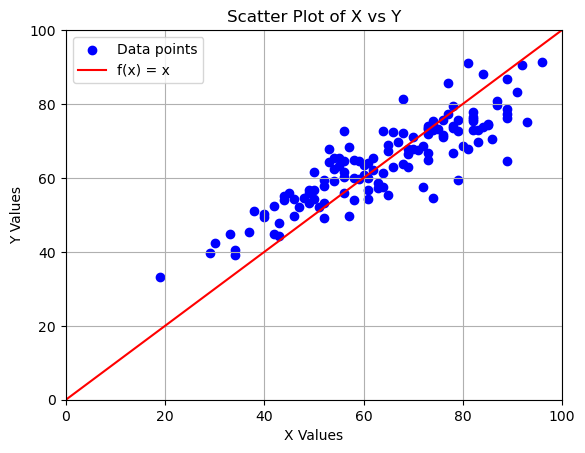

In [ ]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')

# Add the f(x) = x line THE REAL AGE THAT THE BLUE DOTS SHOULD CONVERGE TO
x_line = np.linspace(0, 100, 400)
y_line = x_line  # Since f(x) = x
plt.plot(x_line, y_line, color='red', label='f(x) = x')

# Add labels and title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title('Scatter Plot of X vs Y')
plt.xlim(0, 100)  # Set the limits for x-axis
plt.ylim(0, 100)  # Set the limits for y-axis
plt.legend()

# Show plot
plt.grid(True)
plt.show()

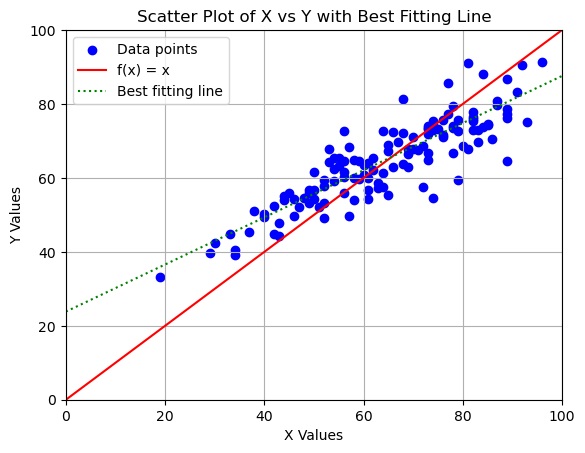

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming y_test and test_predictions are already defined as lists
# Example:
# y_test = [1, 2, 3, 4, 5]             # Actual values
# test_predictions = [1.1, 1.9, 3.2, 4.0, 4.8]  # Predicted values

# Convert lists to NumPy arrays
y_test = np.array(y_test)
test_predictions = np.array(test_predictions)

# Reshape y_test for the model (it should be a 2D array)
y_test_reshaped = y_test.reshape(-1, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(y_test_reshaped, test_predictions)

# Generate values for the best fitting line
x_line = np.linspace(0, 100, 400).reshape(-1, 1)
y_line = model.predict(x_line)

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')

# Add the f(x) = x line (identity line)
plt.plot(x_line, x_line, color='red', label='f(x) = x')

# Plot the best-fitting line from linear regression
plt.plot(x_line, y_line, color='green', label='Best fitting line', linestyle=':')

# Add labels and title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title('Scatter Plot of X vs Y with Best Fitting Line')
plt.xlim(0, 100)  # Set the limits for x-axis
plt.ylim(0, 100)  # Set the limits for y-axis
plt.legend()

# Show plot
plt.grid(True)
plt.show()